In [ ]:
using Distributed
addprocs(12)
@everywhere using LatticeDecoder


@everywhere function random_bitstring!(b::Vector{Int64}, n)
    @inbounds for i = 1:n
        b[i] = rand(0:1)
    end
end


@everywhere function random_encoding_experiment(H, σ, max_iter, samples, decoder)
    errors = 0
    n = size(H, 1)
    b = zeros(Int64, n)
    G = generator_matrix(H)
    tg = initialize_tanner_graph(H)
    errors = @distributed (+) for i = 1:samples
        random_bitstring!(b, n)
        y = encode(b, G)
        y .+= sample_error(σ, n)
        bp_result = run_belief_propagation!(tg, y, σ, max_iter, decoder)
        dec = hard_decision(bp_result, H)
        count_symbol_errors(dec, b)
    end
    return errors / samples / size(H, 1)
end


"""
    agresti_coull_confidence_interval(p, n, z=1.96)

Compute the Agresti-Coull confidence interval for a binomial distribution.
The default value of z is for a 95% confidence interval.
To get the 99% confidence interval, use z=2.576.
To get the 99.9% confidence interval, use z=3.291.

"""
function agresti_coull_confidence_interval(p, n, z=1.96)
    p̂ = p
    n̂ = n
    z = z
    p̂_ = (n̂ * p̂ + z^2 / 2) / (n̂ + z^2)
    n̂_ = n̂ + z^2
    return z * sqrt(p̂_ * (1 - p̂_) / n̂_)
end

agresti_coull_confidence_interval

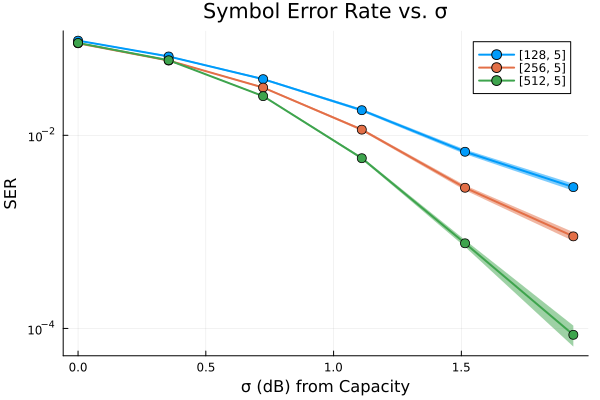

In [2]:

using Plots

samples = 1500;
max_iter = 25;
σ = lattice_capacity_std();
p = plot();
sigmas = range(σ, 0.8 * σ, 6);

decoder = "lsd";
d = 5;
for n in [128, 256, 512]
    H = classical_ldlc(d, n, true)
    ber = [random_encoding_experiment(H, σ, max_iter, samples, decoder) for σ in sigmas]
    ribbon = agresti_coull_confidence_interval.(ber, samples * n)
    plot!(p, snr_db.(sigmas), ber, xlabel="σ (dB) from Capacity", ylabel="SER", label="[$(n), $(d)]", title="Symbol Error Rate vs. σ", lw=2,
        marker=:circle, markersize=5, grid=true, ribbon=ribbon)
end

plot!(p, yscale=:log10)
display(p)